In [1]:
# from copy import deepcopy

import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az
# from scipy.stats import beta, binom
from scipy.special import expit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

---

## Load Data for Prior

In [2]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

In [3]:
statewide = past_vote_df[
    ["Total Votes Gov 2021 2P", "Murphy Votes", "RV 2021", "Total Votes GE 2024 2P", "Harris Votes", "RV 2024", "Current RV"]].sum()

In [4]:
statewide["% Murphy 2P"] = statewide["Murphy Votes"] / statewide["Total Votes Gov 2021 2P"]
statewide["% 2P Turnout 2021"] = statewide["Total Votes Gov 2021 2P"] / statewide["RV 2021"]
statewide["% Harris 2P"] = statewide["Harris Votes"] / statewide["Total Votes GE 2024 2P"]
statewide["% 2P Turnout 2024"] = statewide["Total Votes GE 2024 2P"] / statewide["RV 2024"]
statewide["Margin Murphy Harris"] = statewide["% Harris 2P"] - statewide["% Murphy 2P"]

In [5]:
statewide.round(3)

Total Votes Gov 2021 2P    2594656.000
Murphy Votes               1339471.000
RV 2021                    6575904.000
Total Votes GE 2024 2P     4188928.000
Harris Votes               2220713.000
RV 2024                    6729969.000
Current RV                 6574692.000
% Murphy 2P                      0.516
% 2P Turnout 2021                0.395
% Harris 2P                      0.530
% 2P Turnout 2024                0.622
Margin Murphy Harris             0.014
dtype: float64

---

## Load Survey Data

In [6]:
survey_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="GE", parse_dates=["end_date"], dtype={"FIPS" : str})

In [7]:
survey_df["partisan"].value_counts()

partisan
0      21
GOP     6
Dem     1
Name: count, dtype: int64

In [8]:
survey_reduced_df = survey_df[
    ["pollster", "end_date", "population", "mode", "Sample Size 2P", "moe", "partisan", "Sherrill 2P", "Margin 2P"]].copy()

In [9]:
survey_reduced_df["Sherrill 2P"] = survey_reduced_df["Sherrill 2P"] / 100
survey_reduced_df["Sherrill 2P Lower"] = survey_reduced_df["Sherrill 2P"] - (survey_reduced_df["moe"] / 100)
survey_reduced_df["Sherrill 2P Upper"] = survey_reduced_df["Sherrill 2P"] + (survey_reduced_df["moe"] / 100)

In [10]:
survey_reduced_df

,pollster,end_date,population,mode,Sample Size 2P,moe,partisan,Sherrill 2P,Margin 2P,Sherrill 2P Lower,Sherrill 2P Upper
0,SurveyUSA / Democrats for Education Reform,2025-05-30,lv,unknown,507,6.1,Dem,0.573034,14.606742,0.512034,0.634034
1,National Research,2025-06-12,lv,unknown,522,4.0,GOP,0.517241,3.448276,0.477241,0.557241
2,Rutgers-Eagleton,2025-06-16,rv,panel,473,5.2,0,0.621951,24.390244,0.569951,0.673951
3,Change NJ,2025-06-27,lv,phone,712,3.5,GOP,0.528090,5.617978,0.493090,0.563090
4,Fairleigh Dickinson,2025-07-23,lv,phone / text-to-web,677,3.4,0,0.548780,9.756098,0.514780,0.582780
5,StimSight / InsiderNJ,2025-07-24,lv,phone / text-to-web,1008,3.3,0,0.533333,6.666667,0.500333,0.566333
6,Rutgers-Eagleton,2025-08-11,lv,panel,1320,3.7,0,0.556962,11.392405,0.519962,0.593962
7,TIPP / League of American Workers,2025-08-28,rv,panel,1113,3.0,GOP,0.506849,1.369863,0.476849,0.536849
8,TIPP / League of American Workers,2025-08-28,lv,panel,1160,3.0,GOP,0.541176,8.235294,0.511176,0.571176
9,Quantus Insights,2025-09-04,lv,panel / text-to-web,504,4.3,0,0.559524,11.904762,0.516524,0.602524


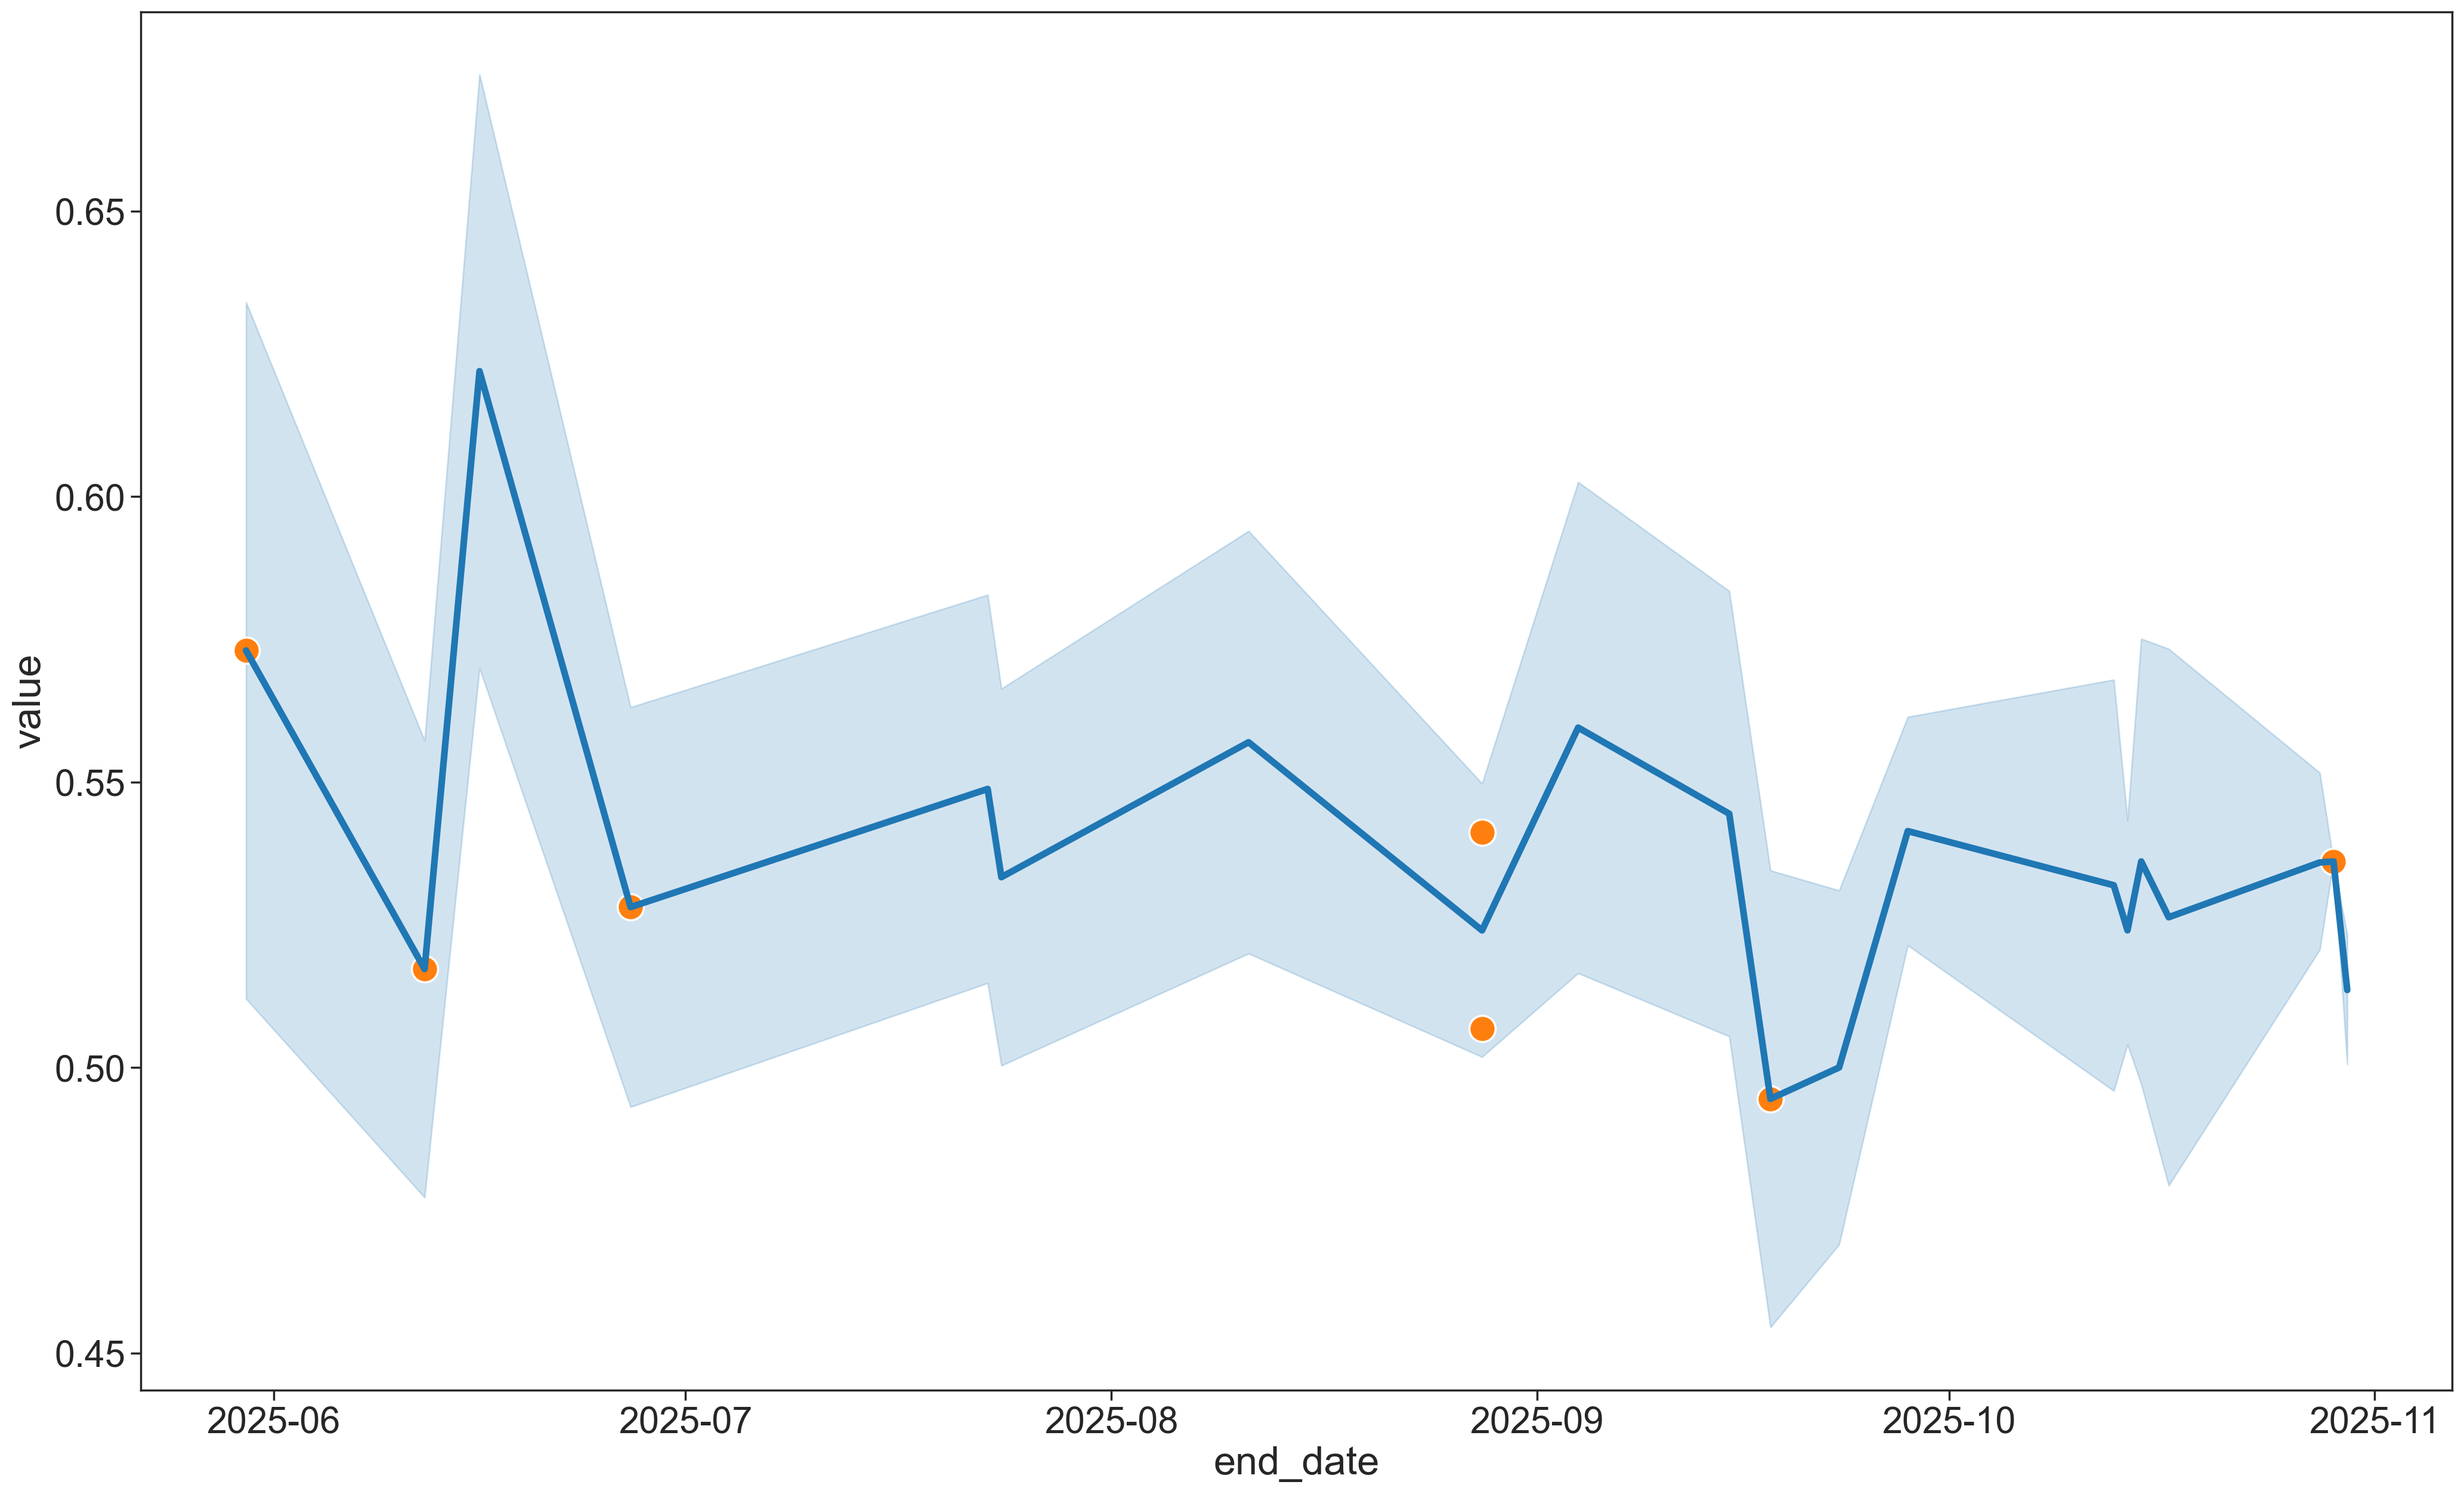

In [11]:
for_plot = survey_reduced_df[["end_date", "partisan", "Sherrill 2P", "Sherrill 2P Lower", "Sherrill 2P Upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "partisan"])

ax = sns.lineplot(data=for_plot, x="end_date", y="value", linewidth=4, color="tab:blue")
sns.scatterplot(data=survey_reduced_df[survey_reduced_df["partisan"] != 0], x="end_date", y="Sherrill 2P", s=250, color="tab:orange")
plt.show()

<Axes: xlabel='value', ylabel='Count'>

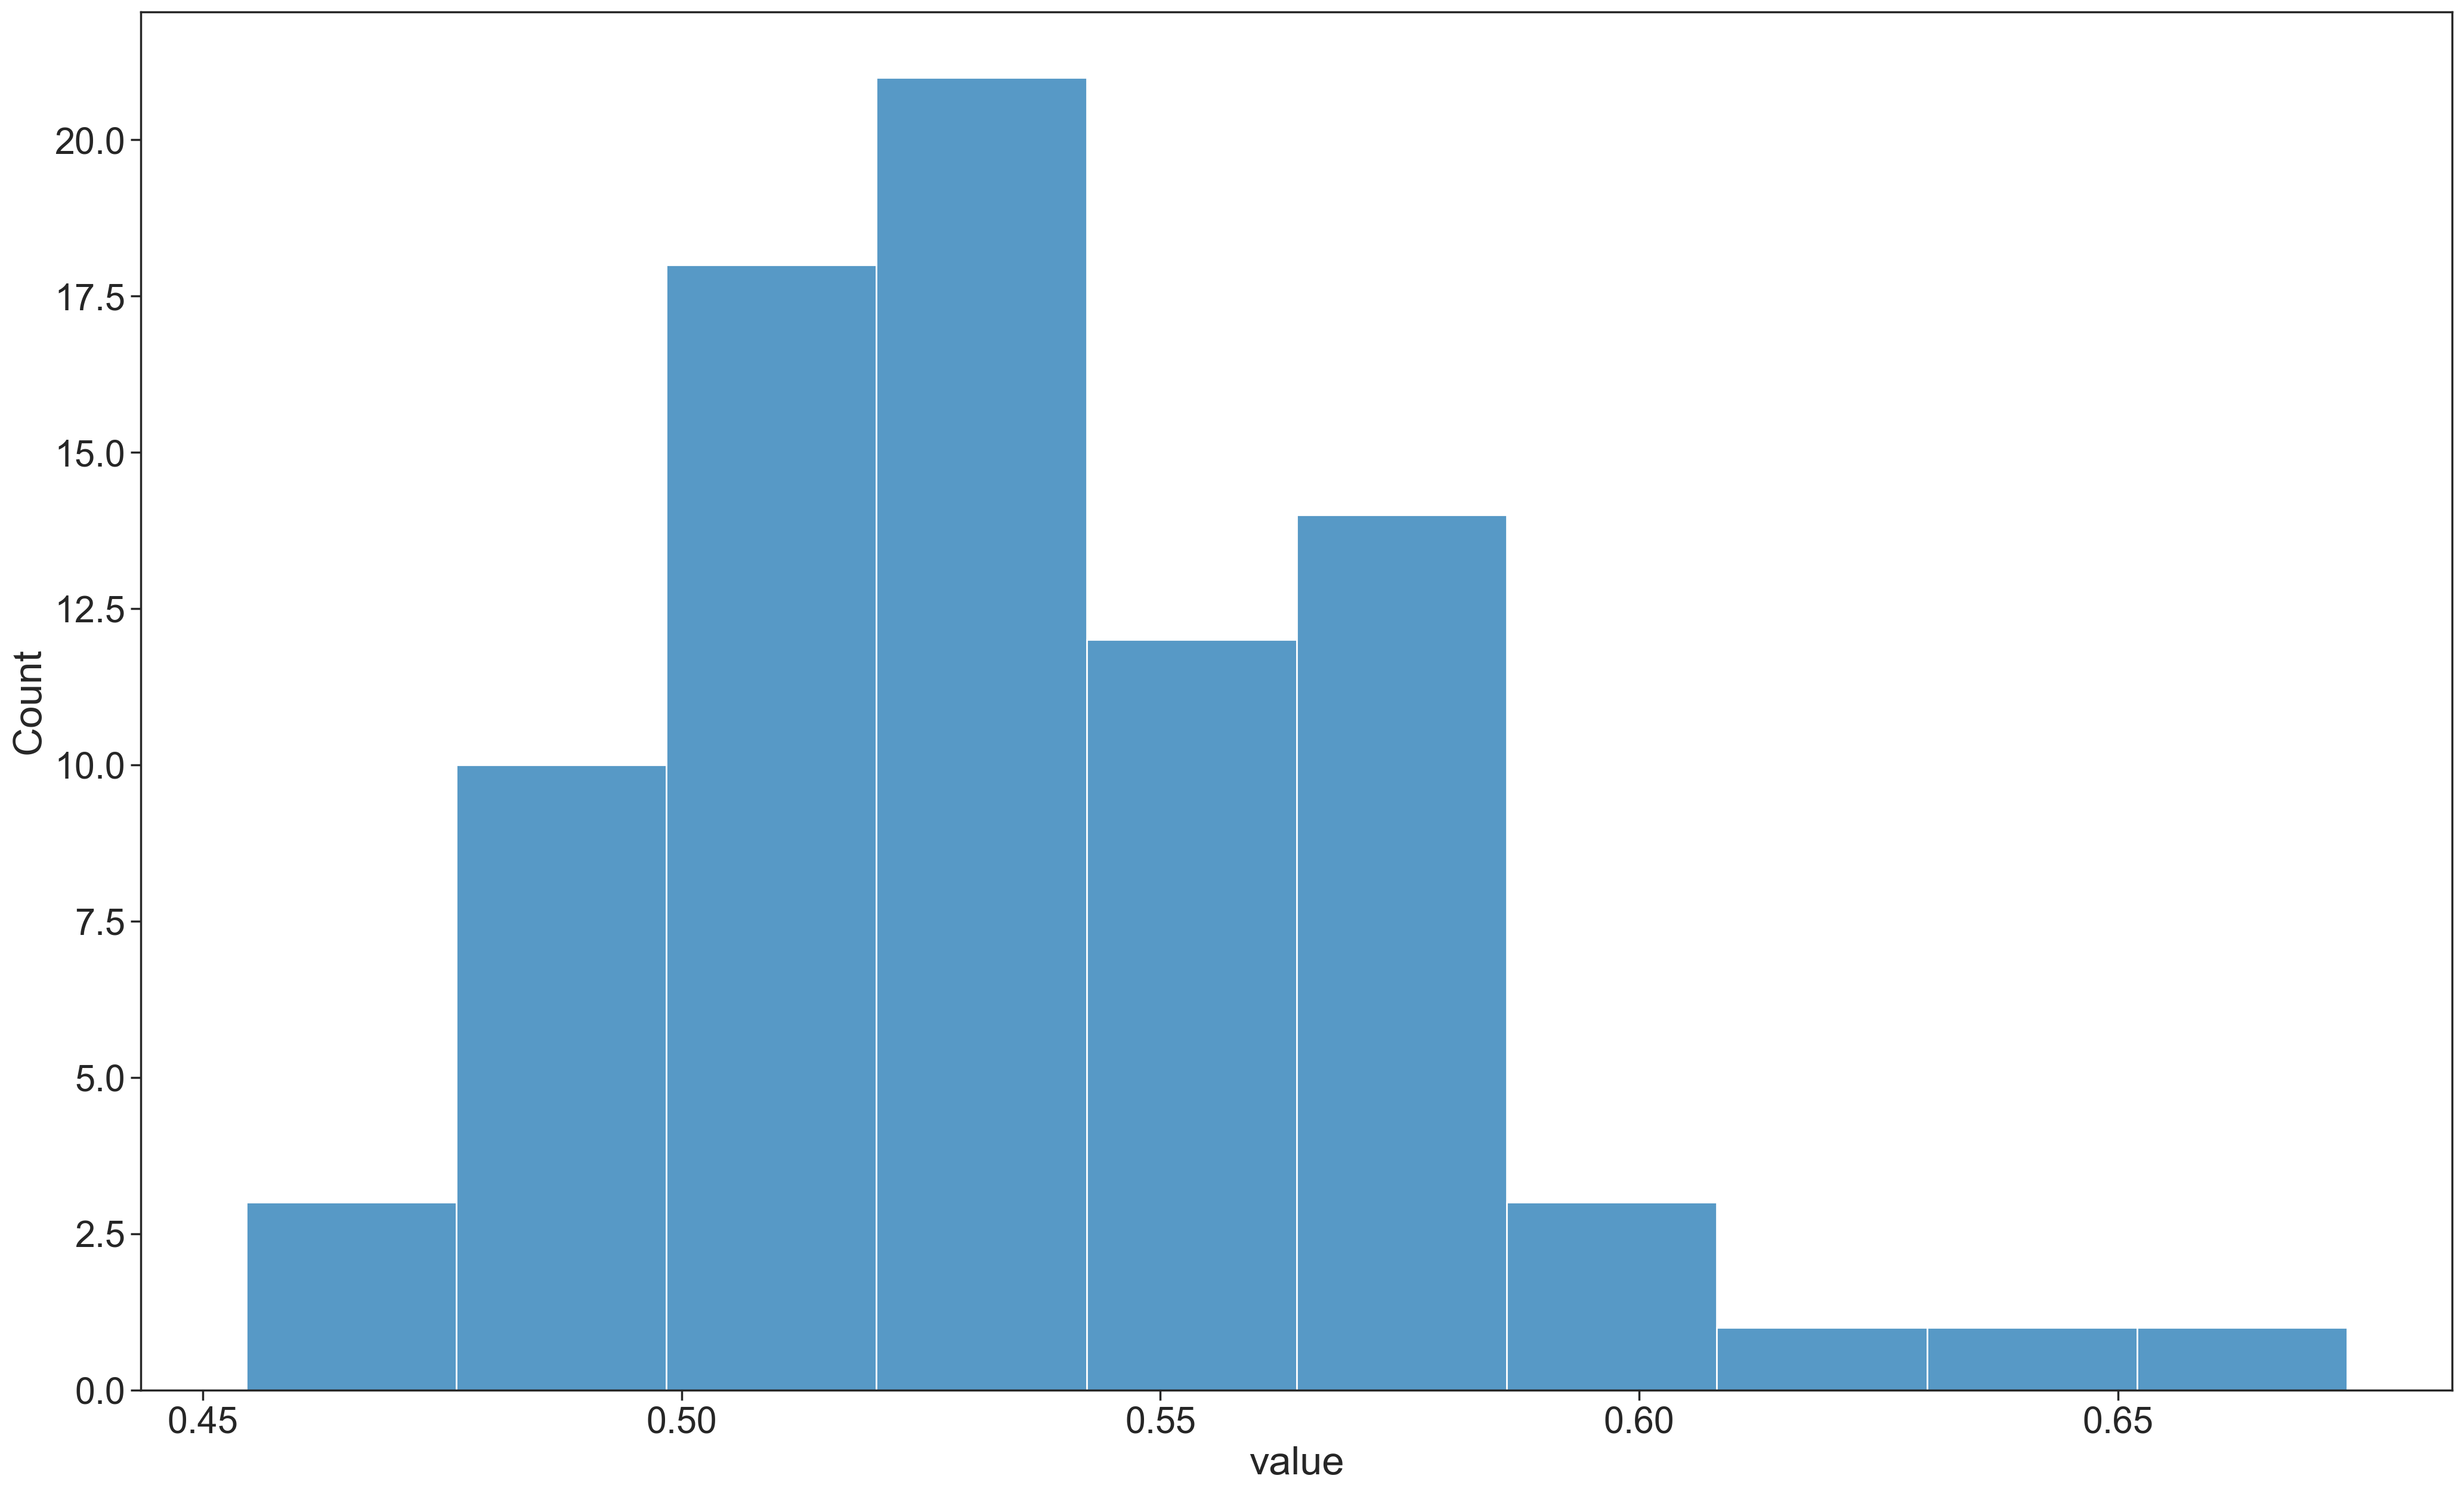

In [12]:
sns.histplot(x=for_plot["value"], color="tab:blue")

In [13]:
for_plot.groupby(["partisan"]).agg({"value" : "mean"})

,value
partisan,
0,0.537946
Dem,0.573034
GOP,0.520658


In [14]:
survey_reduced_df

,pollster,end_date,population,mode,Sample Size 2P,moe,partisan,Sherrill 2P,Margin 2P,Sherrill 2P Lower,Sherrill 2P Upper
0,SurveyUSA / Democrats for Education Reform,2025-05-30,lv,unknown,507,6.1,Dem,0.573034,14.606742,0.512034,0.634034
1,National Research,2025-06-12,lv,unknown,522,4.0,GOP,0.517241,3.448276,0.477241,0.557241
2,Rutgers-Eagleton,2025-06-16,rv,panel,473,5.2,0,0.621951,24.390244,0.569951,0.673951
3,Change NJ,2025-06-27,lv,phone,712,3.5,GOP,0.528090,5.617978,0.493090,0.563090
4,Fairleigh Dickinson,2025-07-23,lv,phone / text-to-web,677,3.4,0,0.548780,9.756098,0.514780,0.582780
5,StimSight / InsiderNJ,2025-07-24,lv,phone / text-to-web,1008,3.3,0,0.533333,6.666667,0.500333,0.566333
6,Rutgers-Eagleton,2025-08-11,lv,panel,1320,3.7,0,0.556962,11.392405,0.519962,0.593962
7,TIPP / League of American Workers,2025-08-28,rv,panel,1113,3.0,GOP,0.506849,1.369863,0.476849,0.536849
8,TIPP / League of American Workers,2025-08-28,lv,panel,1160,3.0,GOP,0.541176,8.235294,0.511176,0.571176
9,Quantus Insights,2025-09-04,lv,panel / text-to-web,504,4.3,0,0.559524,11.904762,0.516524,0.602524


In [15]:
survey_reduced_df["num_for"] = (survey_reduced_df["Sherrill 2P"] * survey_reduced_df["Sample Size 2P"]).round(0)
survey_reduced_df["num_for_lower"] = (survey_reduced_df["Sherrill 2P Lower"] * survey_reduced_df["Sample Size 2P"]).round(0)
survey_reduced_df["num_for_upper"] = (survey_reduced_df["Sherrill 2P Upper"] * survey_reduced_df["Sample Size 2P"]).round(0)

In [16]:
survey_reduced_df = survey_reduced_df.melt(id_vars=[c for c in survey_reduced_df.columns if not c.startswith("num_for")],)
survey_reduced_df = survey_reduced_df.rename(columns={"value" : "num_for"})

---

## Use Survey Data to Model State-Level

In [17]:
partisan_id, partisans = survey_reduced_df["partisan"].factorize(sort=False)

In [18]:
date_id, dates = survey_reduced_df.sort_values(by=["end_date"])["end_date"].dt.to_period("D").factorize(sort=False)
dates = [str(d) for d in dates]

In [19]:
# survey_reduced_df["mode_pop"] = survey_reduced_df.apply(lambda x : " / ".join([x["mode"], x["population"]]), axis=1)
# mode_pop_id, mode_pop = survey_reduced_df["mode_pop"].factorize(sort=False)

# pop_id, population = survey_reduced_df["population"].factorize(sort=False)

In [20]:
coords = {
    "partisan" : partisans,
    # "mode_pop" : mode_pop,
    # "population" : population,
    "day" : dates
}

In [21]:
with pm.Model(coords=coords) as state_model:
    # prior
    prior_pct = pm.Beta("prior_pct",
                        mu=statewide[["% Murphy 2P", "% Harris 2P"]].mean(),
                        sigma=statewide[["% Murphy 2P", "% Harris 2P"]].std(ddof=1))

    # effects
    partisan_effect = pm.TruncatedNormal("partisan_effect", mu=0.5, upper=1, lower=0, sigma=0.15, dims="partisan")
    sigma_mu = pm.HalfNormal("sigma_mu", 0.5)
    date_effect = pm.GaussianRandomWalk("date_effect", sigma=sigma_mu, dims="day")
    # pop_effect = pm.Normal("pop_effect", 0, 0.15, dims="population")

    # likelihood
    popularity = pm.math.invlogit(prior_pct + partisan_effect[partisan_id] + date_effect[date_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=survey_reduced_df["Sample Size 2P"],
        observed=survey_reduced_df["num_for"]
    )

/Users/napolitanod/miniconda3/lib/python3.13/site-packages/pymc/distributions/timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [22]:
with state_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [prior_pct, partisan_effect, sigma_mu, date_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 18 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


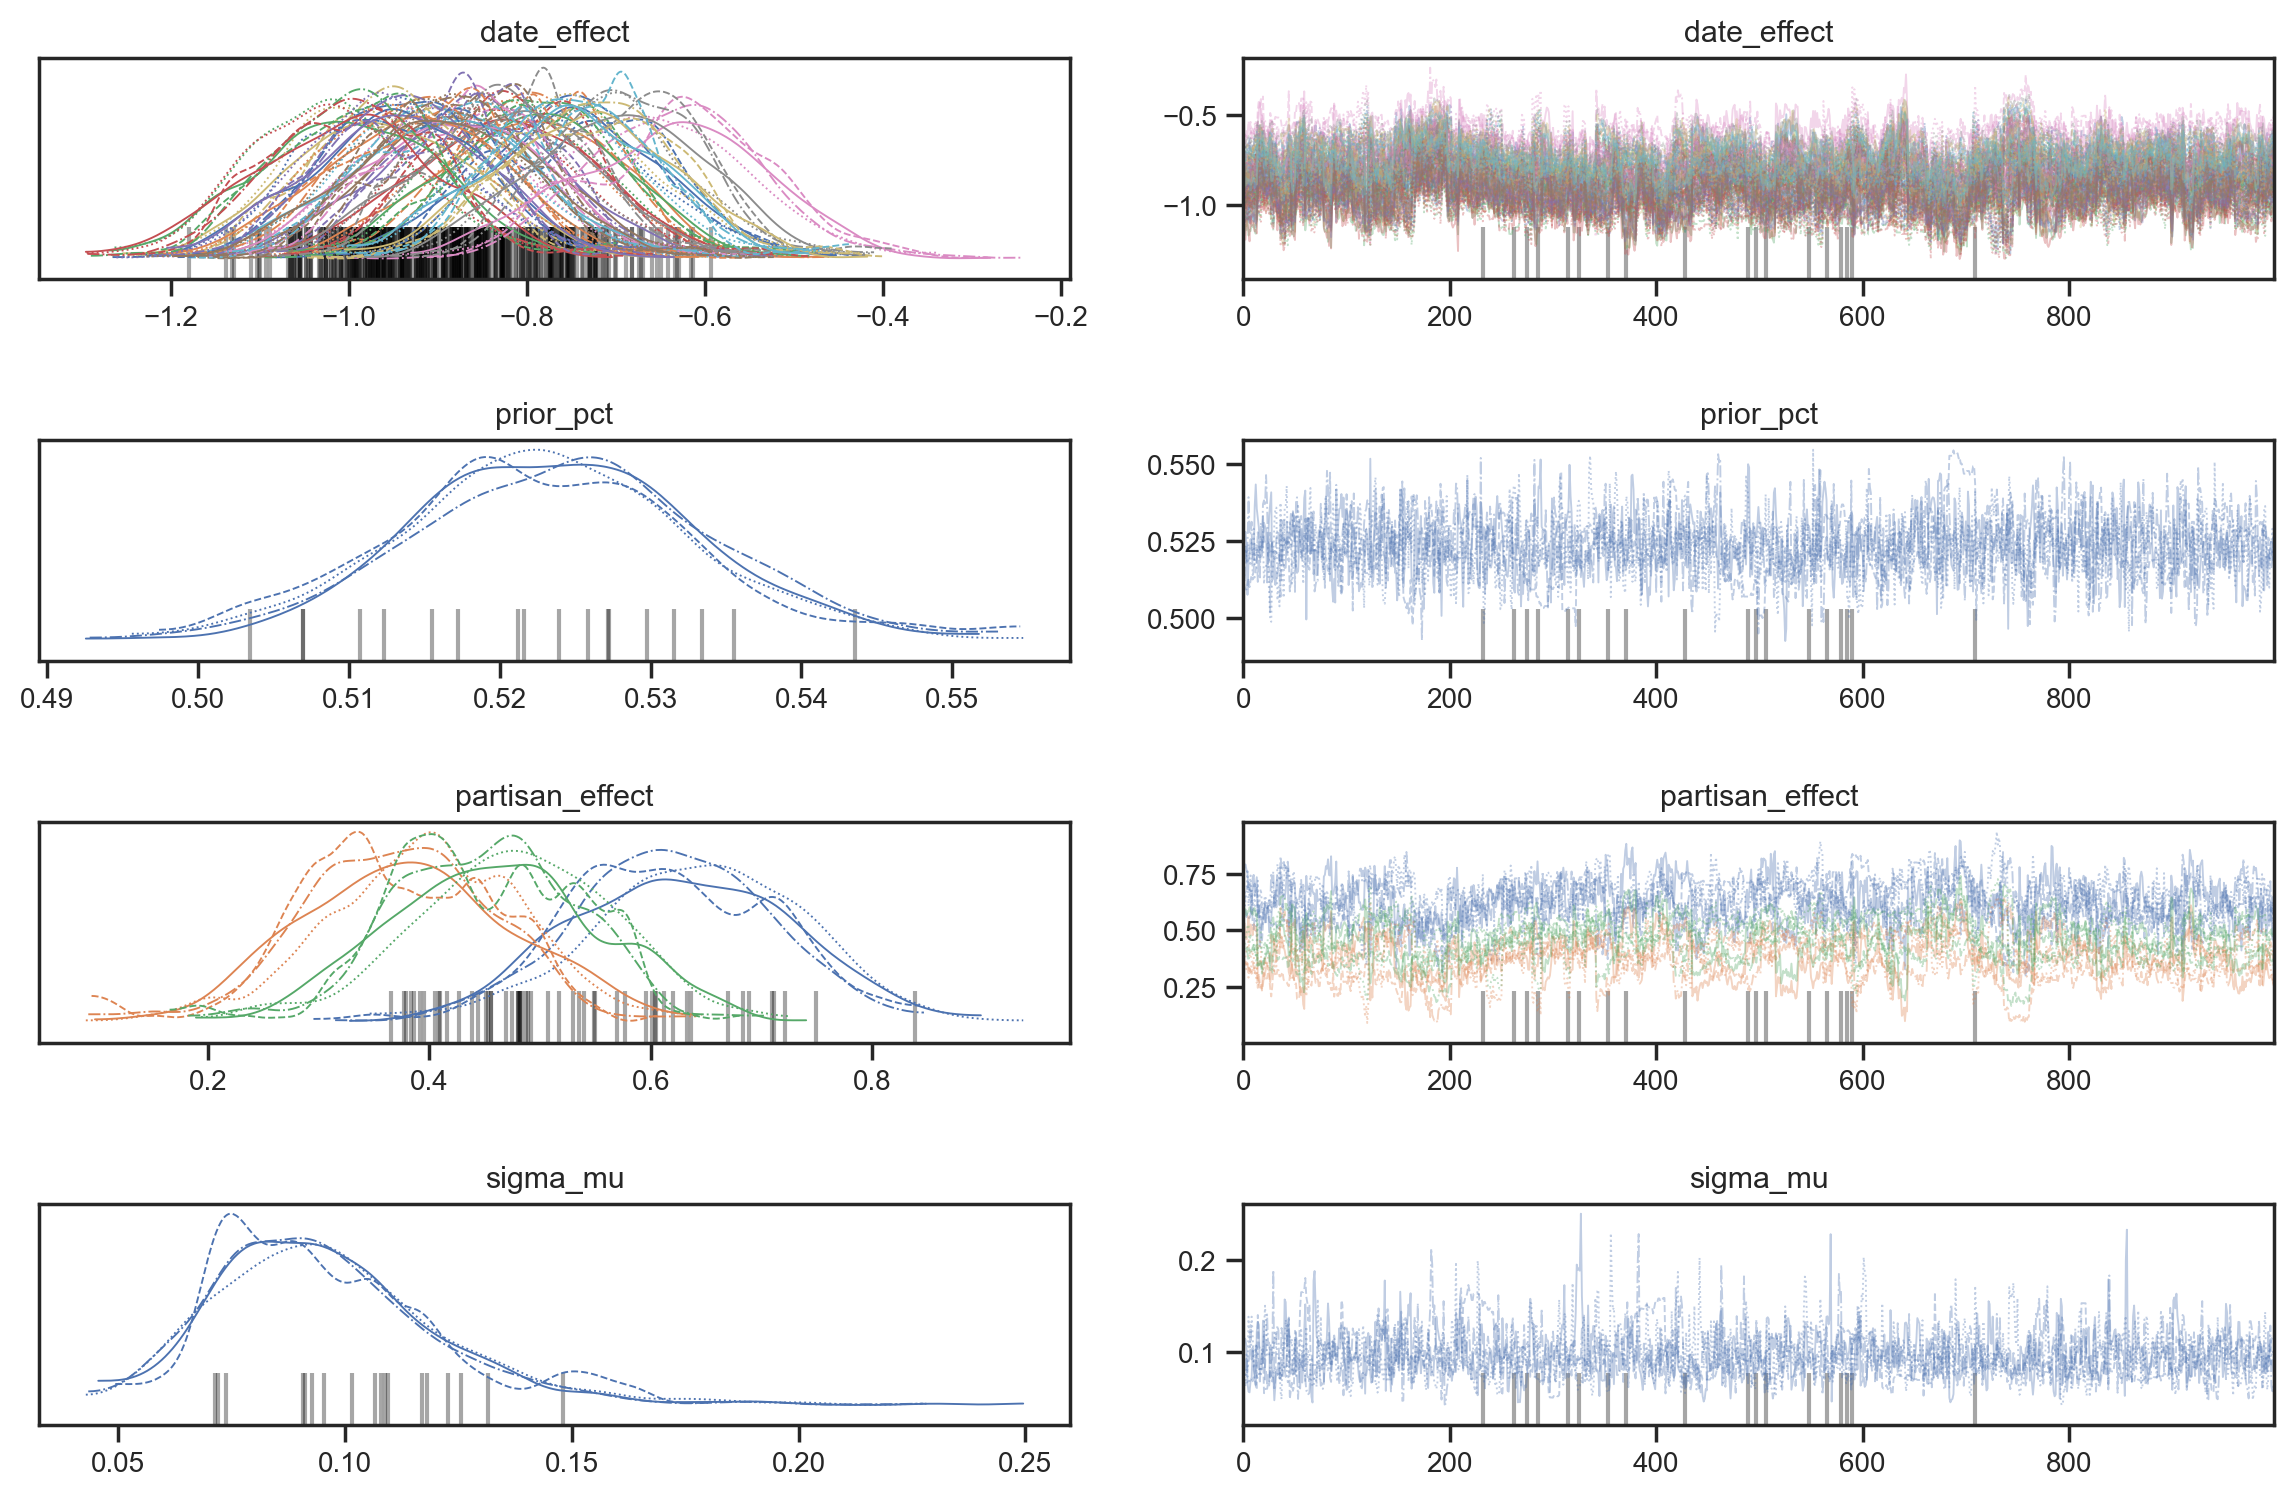

In [23]:
az.plot_trace(idata);
plt.tight_layout()

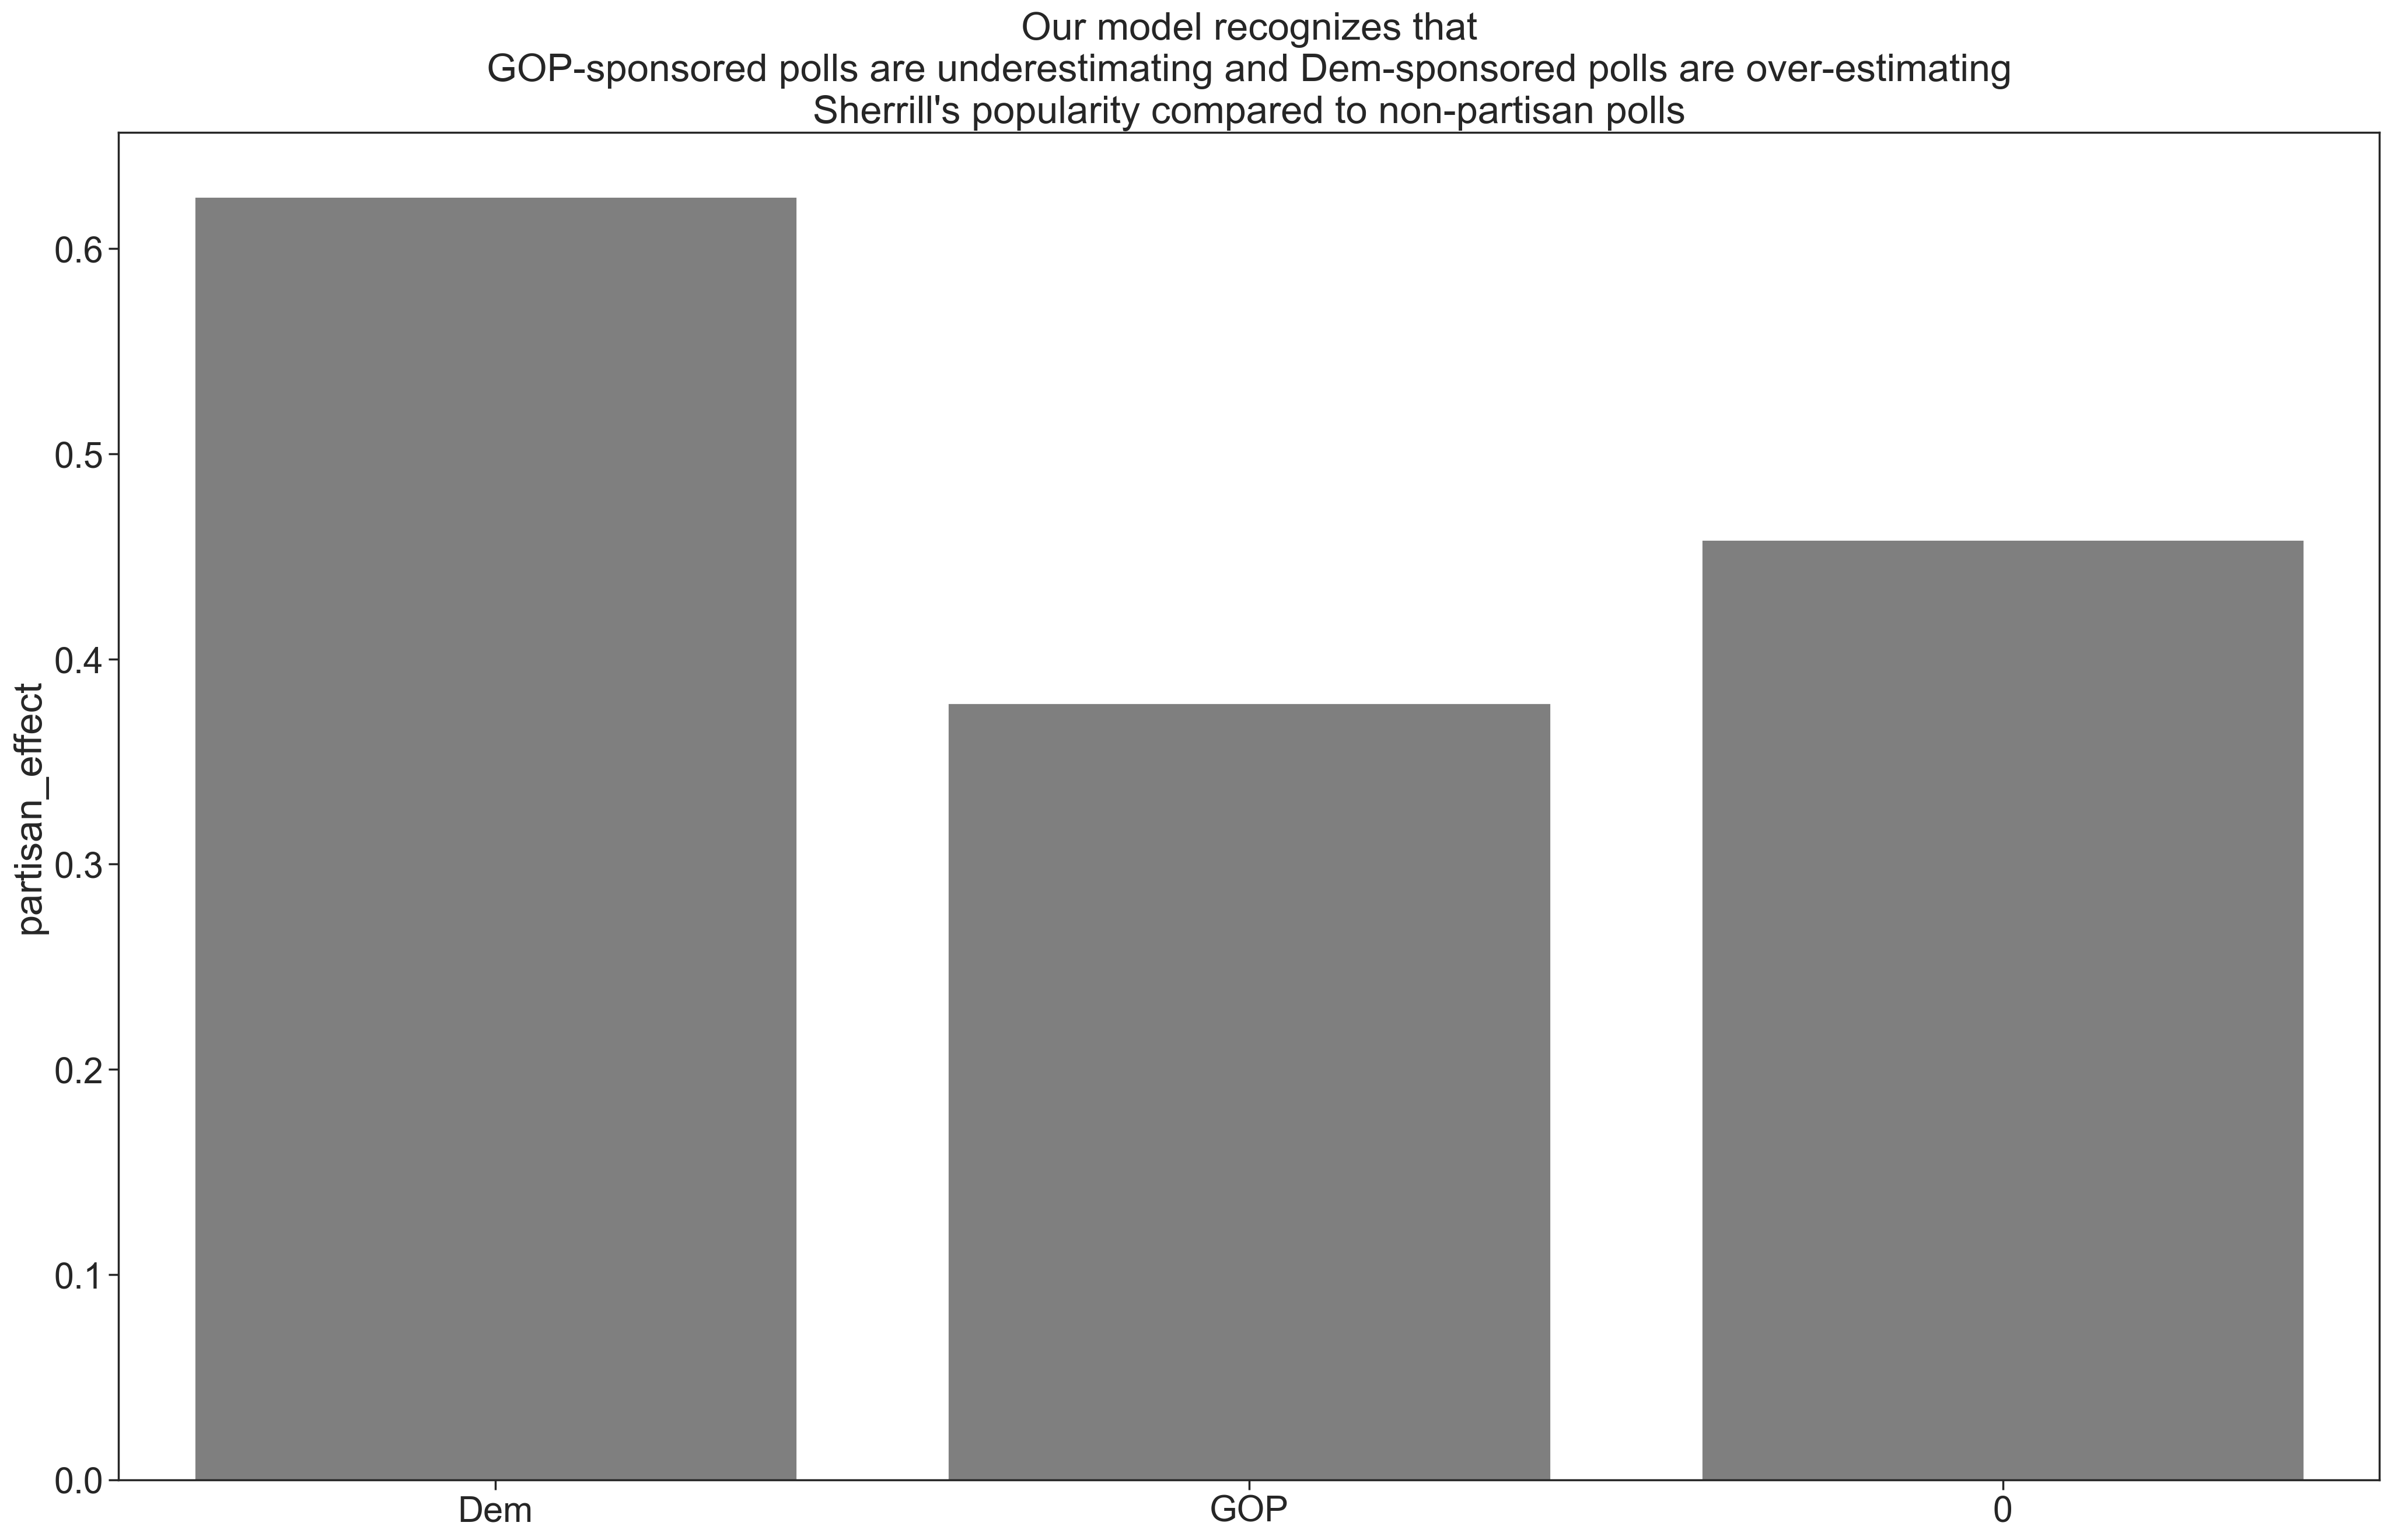

In [24]:
mean_kind_effect = (idata.posterior["partisan_effect"].mean(("chain", "draw")).to_dataframe()).reset_index()
ax = sns.barplot(data=mean_kind_effect, x="partisan", y="partisan_effect", color="tab:grey")
ax.set_title("Our model recognizes that\nGOP-sponsored polls are underestimating and Dem-sponsored polls are over-estimating\nSherrill's popularity compared to non-partisan polls")
ax.set_xlabel(None)
plt.show()

In [25]:
with state_model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [26]:
pred_pct = expit(idata.posterior["prior_pct"]
                 + idata.posterior["partisan_effect"]
                 + idata.posterior["date_effect"]).stack(sample=("chain", "draw", "partisan", "day"))
pred_pct

<xarray.DataArray (sample: 240000)> Size: 2MB
array([0.5892973 , 0.59629944, 0.59687135, ..., 0.56661034, 0.56480048,
       0.55429463], shape=(240000,))
Coordinates:
  * sample    (sample) object 2MB MultiIndex
  * chain     (sample) int64 2MB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw      (sample) int64 2MB 0 0 0 0 0 0 0 0 ... 999 999 999 999 999 999 999
  * partisan  (sample) <U21 20MB 'Dem' 'Dem' 'Dem' 'Dem' ... '0' '0' '0' '0'
  * day       (sample) <U10 10MB '2025-05-30' '2025-06-12' ... '2025-10-30'

In [27]:
post_R = 1 - pred_pct
margin = (pred_pct - post_R) * 100

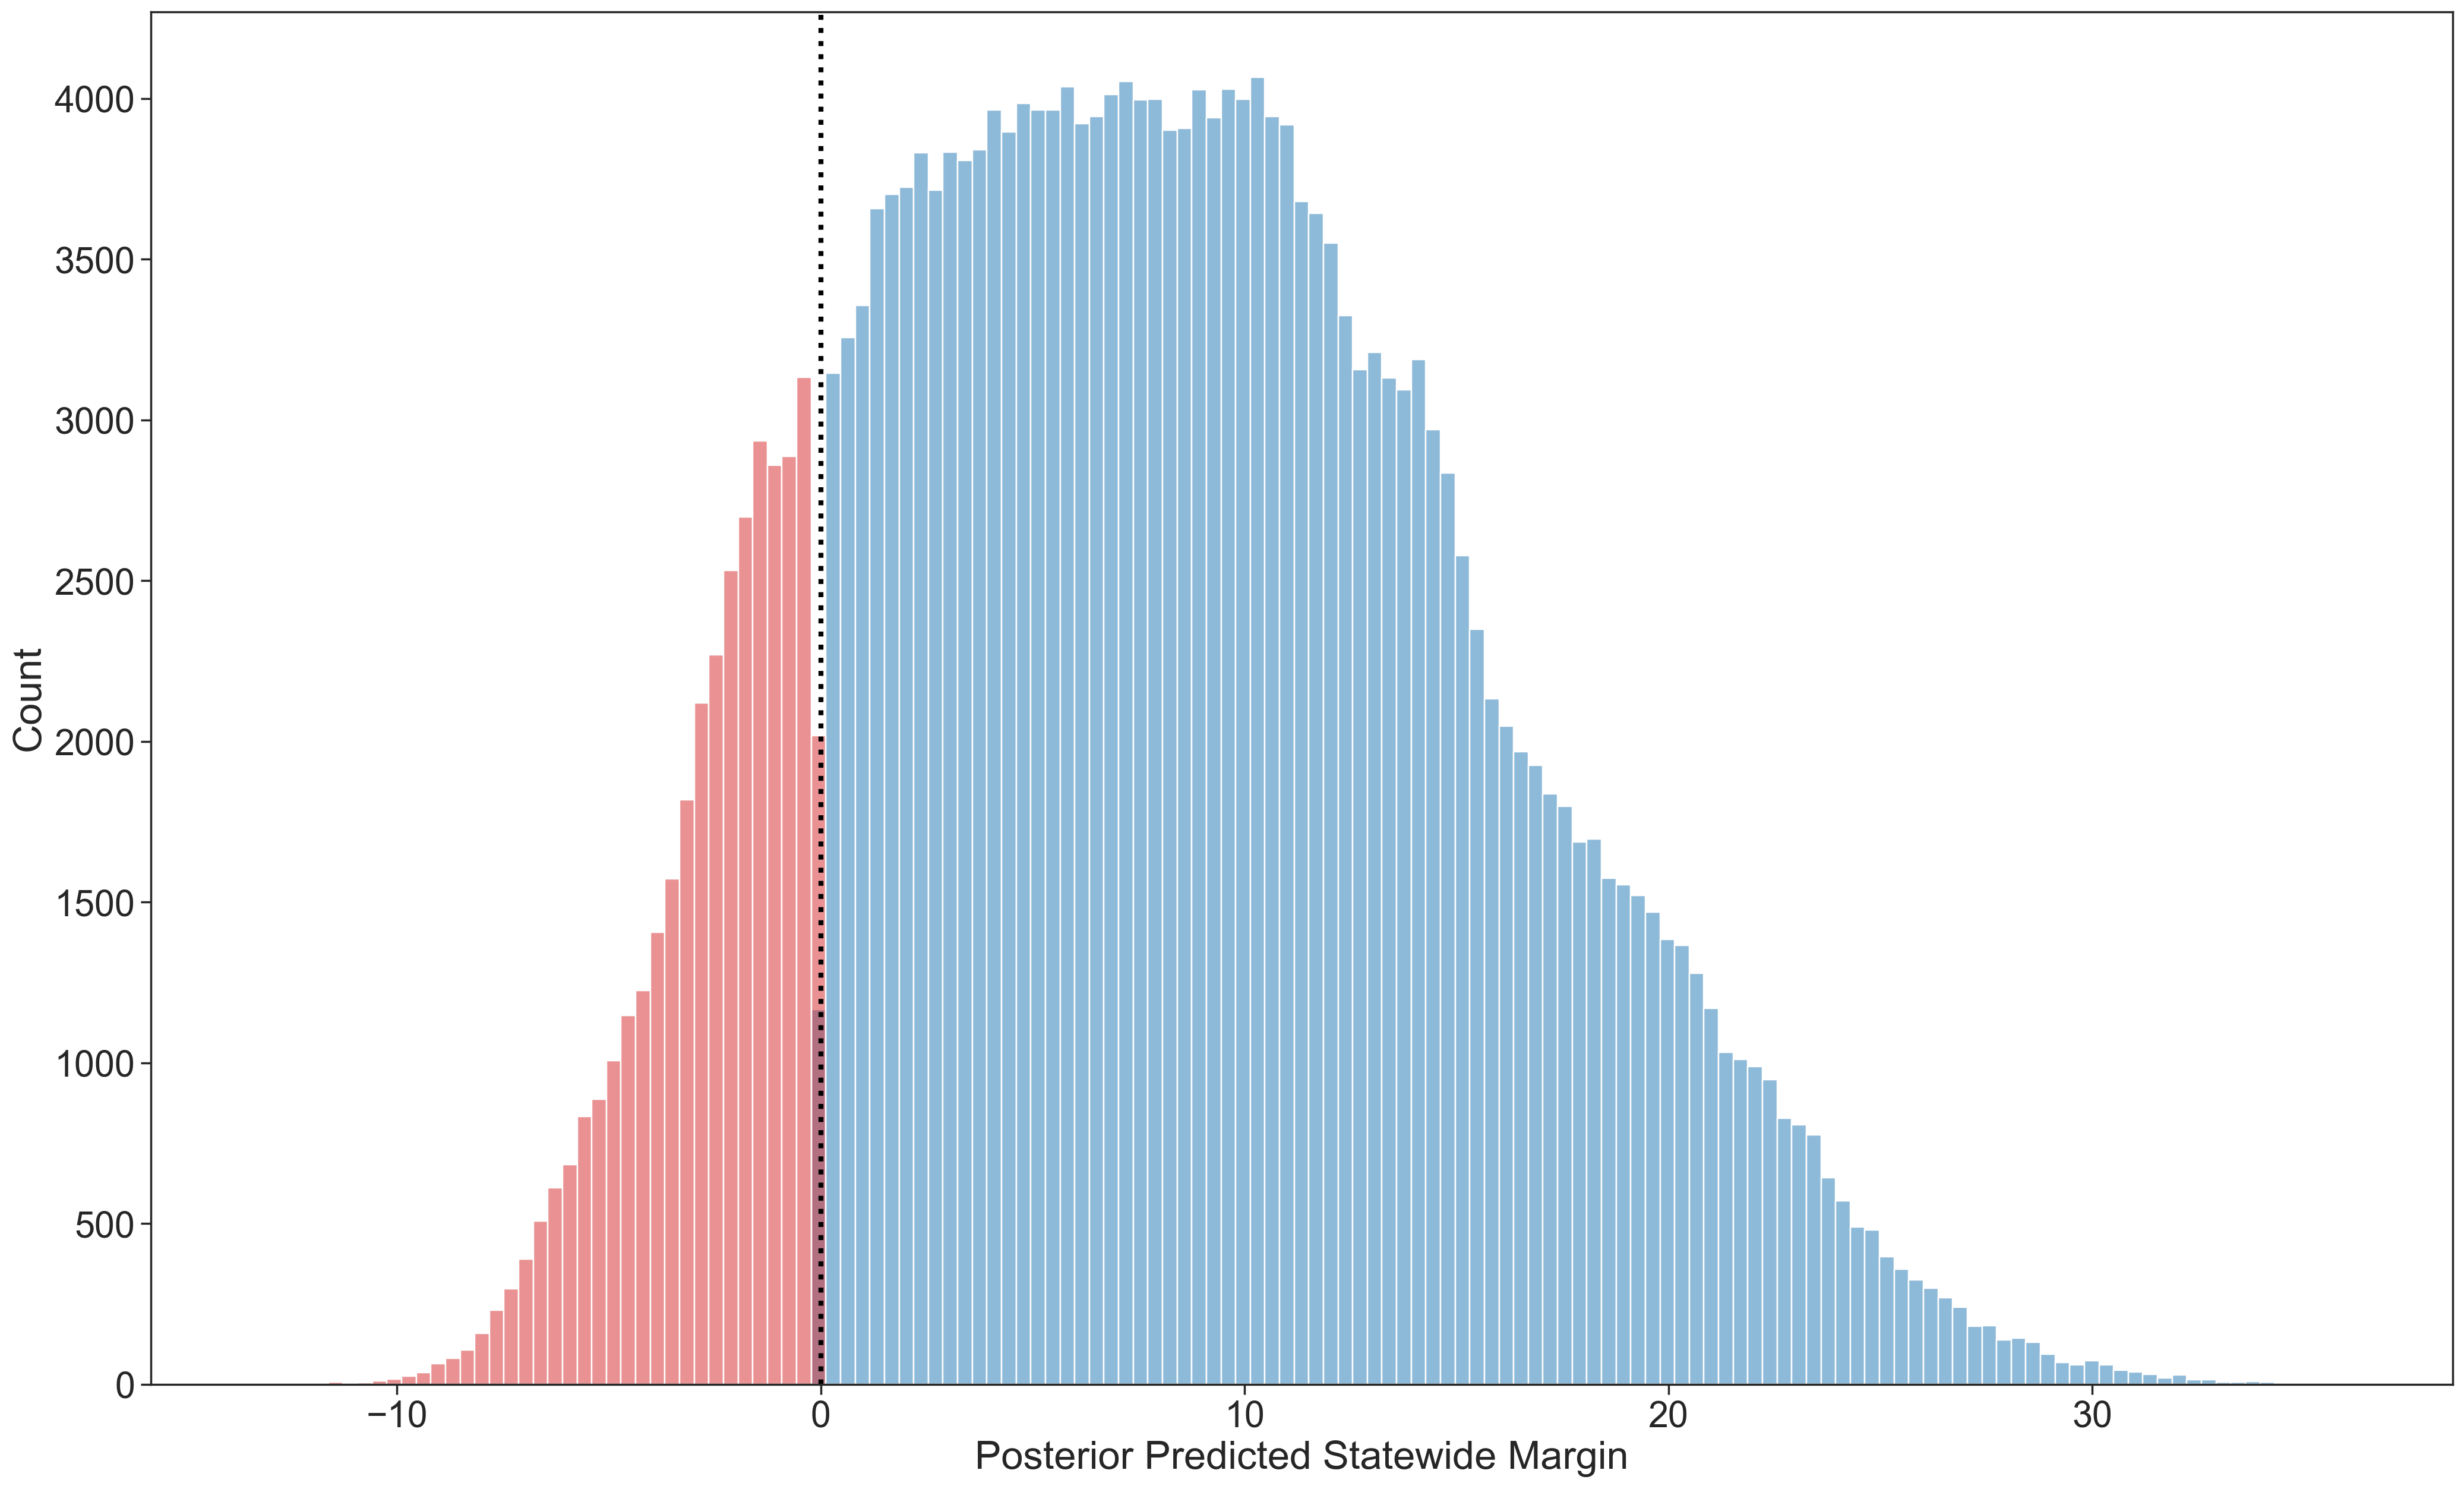

In [28]:
for_plot = pandas.DataFrame(margin, columns=["margin"])
for_plot["+D"] = for_plot["margin"] > 0

ax = sns.histplot(data=for_plot, x="margin", hue="+D", palette={True : "tab:blue", False : "tab:red"}, legend=False)
ax.axvline(x=0, linewidth=3, linestyle=":", color="black", label="Tie")
# ax.legend()
ax.set_xlabel("Posterior Predicted Statewide Margin")
plt.show()

In [29]:
(np.quantile(margin.values, 0.025), np.mean(margin.values), np.quantile(margin.values, 0.975))

(np.float64(-4.69374620647317),
 np.float64(8.003255899827742),
 np.float64(23.352014644844378))